## Training vs Validation Behavior

### What does each of these indicate?
- train loss ↓, validation loss ↓
    - The model is learning useful patterns and currently generalizing to the validation data.

- train loss ↓, validation loss ↑ 
    - The model is likely overfitting: it continues improving on the training data while its performance on unseen validation data deteriorates.
    
- train loss ≈ constant, validation loss ≈ constant 
    - The model is not learning effectively. This can indicate underfitting, but other causes such as an unsuitable learning rate, optimization problems, poor initialization, or data/preprocessing issues must also be investigated.

### Which pattern indicates overfitting?
- When training loss keeps decreasing and validation loss starts increasing.

### Which pattern suggests the model isn't learning effectively?
- When both training and validation loss remains approx. constant.

## CNN Model to experiment with

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd

train_set = pd.read_csv("../../datasets/fashion_mnist_dataset/fashion-mnist_train.csv")
test_set = pd.read_csv("../../datasets/fashion_mnist_dataset/fashion-mnist_test.csv")

train_images = torch.tensor(
    train_set.iloc[:, 1:].to_numpy().reshape(-1, 1, 28, 28),
    dtype=torch.float32
)

train_labels = torch.tensor(
    train_set.iloc[:, 0].to_numpy(),
    dtype=torch.long
)

test_images = torch.tensor(
    test_set.iloc[:, 1:].to_numpy().reshape(-1, 1, 28, 28),
    dtype=torch.float32
)

test_labels = torch.tensor(
    test_set.iloc[:, 0].to_numpy(),
    dtype=torch.long
)

train_images = train_images / 255.0
test_images = test_images / 255.0

del train_set, test_set

import gc
gc.collect()

0

In [2]:
class FashionMnistDataset(Dataset):
    
    def __init__(self, X, y):
        super().__init__()
        
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    
val_images = train_images[54000:]
val_labels = train_labels[54000:]

train_images = train_images[:54000]
train_labels = train_labels[:54000]

train_dataset = FashionMnistDataset(train_images, train_labels)
    
val_dataset = FashionMnistDataset(val_images, val_labels)

batch_s = 256
    
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_s,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_s,
    shuffle=False
)  

### Making a function to plot train and validation losses

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_train_val_loss_curve(train_losses, validation_losses, title, ax=None):

    if ax == None:
        plt.figure()       # always start fresh
        ax = plt.gca()
    
    train_losses = np.array(train_losses)
    validation_losses = np.array(validation_losses)

    train_min_idx = np.argmin(train_losses)
    val_min_idx = np.argmin(validation_losses)

    ax.plot(validation_losses, label='Validation Loss')
    ax.plot(train_losses, label="Training Loss")

    ax.scatter(train_min_idx, train_losses[train_min_idx])
    ax.scatter(val_min_idx, validation_losses[val_min_idx])

    ax.annotate(
        f"Epoch {val_min_idx}\n{validation_losses[val_min_idx]:.4f}",
        (float(val_min_idx), validation_losses[val_min_idx]),
        xytext=(10, 10),
        textcoords="offset points",
    )

    ax.annotate(
        f"Epoch {train_min_idx}\n{train_losses[train_min_idx]:.4f}",
        (float(train_min_idx), train_losses[train_min_idx]),
        xytext=(10, -15),
        textcoords="offset points",
    )

    ax.legend()
    ax.set_title(title)
    ax.plot()
    
def plot_train_val_accuracy_curve(train_accuracies, validation_accuracies, title, ax=None):

    if ax == None:
        plt.figure()       # always start fresh
        ax = plt.gca()
    
    train_accuracies = np.array(train_accuracies)
    validation_accuracies = np.array(validation_accuracies)

    train_min_idx = np.argmax(train_accuracies)
    val_min_idx = np.argmax(validation_accuracies)

    ax.plot(validation_accuracies, label='Validation Accuracy')
    ax.plot(train_accuracies, label="Training Accuracy")

    ax.scatter(train_min_idx, train_accuracies[train_min_idx])
    ax.scatter(val_min_idx, validation_accuracies[val_min_idx])

    ax.annotate(
        f"Epoch {val_min_idx}\n{validation_accuracies[val_min_idx]:.4f}",
        (float(val_min_idx), validation_accuracies[val_min_idx]),
        xytext=(10, 10),
        textcoords="offset points",
    )

    ax.annotate(
        f"Epoch {train_min_idx}\n{train_accuracies[train_min_idx]:.4f}",
        (float(train_min_idx), train_accuracies[train_min_idx]),
        xytext=(10, -15),
        textcoords="offset points",
    )

    ax.legend()
    ax.set_title(title)
    ax.plot()

### CNN Model

In [4]:
import torch
import torch.nn as nn

class FashionMnistCNN(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=12, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=12, out_channels=24, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=24, out_channels=48, kernel_size=3, padding=1, stride=1),
            nn.ReLU()
        )
    
        self.classifier = nn.Linear(in_features=7*7*48, out_features=10)
        
    def forward(self, x):
        
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        
        x = self.classifier(x)
        return x

### Training Loop

In [5]:
import os
import gc

fashion_cnn_model = FashionMnistCNN()

device = torch.device("cuda")

fashion_cnn_model = fashion_cnn_model.to(device)

optimizer = torch.optim.Adam(
    fashion_cnn_model.parameters(),
    lr=1e-3
)

fashion_cnn_model_train_losses = []
fashion_cnn_model_val_losses = []
fashion_cnn_model_train_accuracies = []
fashion_cnn_model_val_accuracies = []

loss_fn = nn.CrossEntropyLoss()

best_val_loss = float("inf")

fashion_checkpoint_path = "/home/taksh/Coding/Learn/ml-learning-journey/static/tmp"

if os.path.exists(os.path.join(fashion_checkpoint_path, "best_fashion_cnn_model.pt")):
    fashion_cnn_model.load_state_dict(torch.load(
        os.path.join(fashion_checkpoint_path, "best_fashion_cnn_model.pt"),
        map_location=device
    ))

    fashion_cnn_model_train_losses = np.load(os.path.join(fashion_checkpoint_path, "fashion_cnn_model_train_losses.npy"))
    fashion_cnn_model_val_losses = np.load(os.path.join(fashion_checkpoint_path, "fashion_cnn_model_val_losses.npy"))
    fashion_cnn_model_train_accuracies = np.load(os.path.join(fashion_checkpoint_path, "fashion_cnn_model_train_accuracies.npy"))
    fashion_cnn_model_val_accuracies = np.load(os.path.join(fashion_checkpoint_path, "fashion_cnn_model_val_accuracies.npy"))

if not os.path.exists(os.path.join(fashion_checkpoint_path, "best_fashion_cnn_model.pt")):
    for epoch in range(30):
        
        fashion_cnn_model.train()
            
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            pred = fashion_cnn_model(images)
            
            loss = loss_fn(pred, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            
            correct += (pred.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader)
        train_accuracy = correct / total
            
        # Validation
        fashion_cnn_model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                pred = fashion_cnn_model(images)
                
                loss = loss_fn(pred, labels)

                val_loss += loss.item()
                
                correct += (pred.argmax(dim=1) == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_accuracy = correct / total

        print(
            f"Epoch: {epoch:02} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f} | "
        )
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(fashion_cnn_model.state_dict(), os.path.join(fashion_checkpoint_path, "best_fashion_cnn_model.pt"))

        fashion_cnn_model_train_losses.append(train_loss)
        fashion_cnn_model_val_losses.append(val_loss)
        fashion_cnn_model_train_accuracies.append(train_accuracy)
        fashion_cnn_model_val_accuracies.append(val_accuracy)

    np.save(os.path.join(fashion_checkpoint_path, "fashion_cnn_model_train_losses.npy"), fashion_cnn_model_train_losses)
    np.save(os.path.join(fashion_checkpoint_path, "fashion_cnn_model_val_losses.npy"), fashion_cnn_model_val_losses)
    np.save(os.path.join(fashion_checkpoint_path, "fashion_cnn_model_train_accuracies.npy"), fashion_cnn_model_train_accuracies)
    np.save(os.path.join(fashion_checkpoint_path, "fashion_cnn_model_val_accuracies.npy"), fashion_cnn_model_val_accuracies)

gc.collect()
torch.cuda.empty_cache()

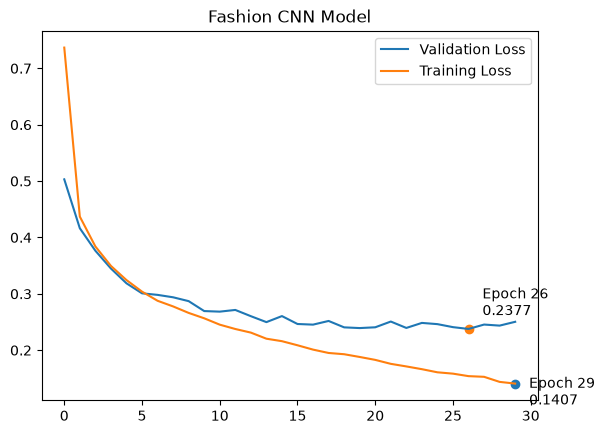

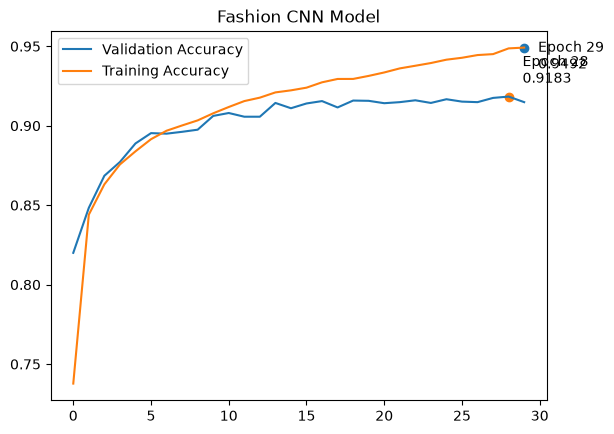

In [6]:
plot_train_val_loss_curve(fashion_cnn_model_train_losses, fashion_cnn_model_val_losses, "Fashion CNN Model")
plot_train_val_accuracy_curve(fashion_cnn_model_train_accuracies, fashion_cnn_model_val_accuracies, "Fashion CNN Model")

## Training Curves

### Why should we track validation performance during training?
- We track validation performance to measure how well the model generalizes to unseen data during training and to detect problems such as overfitting. It also helps us identify which epoch produced the best validation performance.

### Why is the final epoch not necessarily the best model?
- The final epoch is not necessarily the best model because continued training can improve training performance while validation performance deteriorates due to overfitting. Therefore, we often select the checkpoint with the best validation performance rather than automatically using the final epoch.

### Where does learning slow down?
- Learning starts slowing down once the validation loss begins to flatten, roughly around epochs 10–15. Between about epochs 15–25, training loss continues decreasing while validation loss shows only small improvements and fluctuations.

### Is there evidence of overfitting?
- Yes. Around epoch 26, validation loss reaches its minimum. After that, training loss continues decreasing while validation loss begins increasing. This divergence provides evidence that the model is increasingly fitting the training data without improving generalization.

## Packing Training Loop in function

In [7]:
def train_fashion_cnn_model(model, optimizer, loss_fn, postfix):

    fashion_cnn_model = model

    device = torch.device("cuda")

    fashion_cnn_model = fashion_cnn_model.to(device)

    fashion_cnn_model_train_losses = []
    fashion_cnn_model_val_losses = []
    fashion_cnn_model_train_accuracies = []
    fashion_cnn_model_val_accuracies = []

    best_val_loss = float("inf")

    fashion_checkpoint_path = "/home/taksh/Coding/Learn/ml-learning-journey/static/tmp"

    if os.path.exists(os.path.join(fashion_checkpoint_path, f"best_fashion_cnn{postfix}_model.pt")):
        fashion_cnn_model.load_state_dict(torch.load(
            os.path.join(fashion_checkpoint_path, f"best_fashion_cnn{postfix}_model.pt"),
            map_location=device
        ))

        fashion_cnn_model_train_losses = np.load(os.path.join(fashion_checkpoint_path, f"best_fashion_cnn{postfix}_model_train_losses.npy"))
        fashion_cnn_model_val_losses = np.load(os.path.join(fashion_checkpoint_path, f"best_fashion_cnn{postfix}_model_val_losses.npy"))
        fashion_cnn_model_train_accuracies = np.load(os.path.join(fashion_checkpoint_path, f"best_fashion_cnn{postfix}_model_train_accuracies.npy"))
        fashion_cnn_model_val_accuracies = np.load(os.path.join(fashion_checkpoint_path, f"best_fashion_cnn{postfix}_model_val_accuracies.npy"))

    if not os.path.exists(os.path.join(fashion_checkpoint_path, f"best_fashion_cnn{postfix}_model.pt")):
        for epoch in range(30):
            
            fashion_cnn_model.train()
                
            train_loss = 0
            correct = 0
            total = 0

            for images, labels in train_loader:

                images = images.to(device)
                labels = labels.to(device)

                pred = fashion_cnn_model(images)
                
                loss = loss_fn(pred, labels)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                
                correct += (pred.argmax(dim=1) == labels).sum().item()
                total += labels.size(0)

            train_loss /= len(train_loader)
            train_accuracy = correct / total
                
            # Validation
            fashion_cnn_model.eval()

            val_loss = 0
            correct = 0
            total = 0

            with torch.no_grad():

                for images, labels in val_loader:

                    images = images.to(device)
                    labels = labels.to(device)

                    pred = fashion_cnn_model(images)
                    
                    loss = loss_fn(pred, labels)

                    val_loss += loss.item()
                    
                    correct += (pred.argmax(dim=1) == labels).sum().item()
                    total += labels.size(0)

            val_loss /= len(val_loader)
            val_accuracy = correct / total

            print(
                f"Epoch: {epoch:02} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Accuracy: {train_accuracy:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Accuracy: {val_accuracy:.4f} | "
            )
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(fashion_cnn_model.state_dict(), os.path.join(fashion_checkpoint_path, f"best_fashion_cnn{postfix}_model.pt"))

            fashion_cnn_model_train_losses.append(train_loss)
            fashion_cnn_model_val_losses.append(val_loss)
            fashion_cnn_model_train_accuracies.append(train_accuracy)
            fashion_cnn_model_val_accuracies.append(val_accuracy)

        np.save(os.path.join(fashion_checkpoint_path, f"best_fashion_cnn{postfix}_model_train_losses.npy"), fashion_cnn_model_train_losses)
        np.save(os.path.join(fashion_checkpoint_path, f"best_fashion_cnn{postfix}_model_val_losses.npy"), fashion_cnn_model_val_losses)
        np.save(os.path.join(fashion_checkpoint_path, f"best_fashion_cnn{postfix}_model_train_accuracies.npy"), fashion_cnn_model_train_accuracies)
        np.save(os.path.join(fashion_checkpoint_path, f"best_fashion_cnn{postfix}_model_val_accuracies.npy"), fashion_cnn_model_val_accuracies)

    gc.collect()
    torch.cuda.empty_cache()

    plot_train_val_loss_curve(fashion_cnn_model_train_losses, fashion_cnn_model_val_losses, f"Fashion CNN {postfix} Model")
    plot_train_val_accuracy_curve(fashion_cnn_model_train_accuracies, fashion_cnn_model_val_accuracies, f"Fashion CNN {postfix} Model")

## Learning Rate as a Training Control

### What does the learning rate actually control?
- Gradient tells the optimizer which direction and magnitude the loss changes with respect to a parameter; the learning rate determines how large a step the optimizer takes in that direction.

### What happens when it is too large?
- If the learning rate is too large, parameter updates can overshoot low-loss regions, causing the loss to oscillate, become unstable, or even diverge instead of converging.

### What happens when it is too small?
- If the learning rate is too small, parameter updates are very small, causing training to converge very slowly and potentially requiring many epochs to make meaningful progress.

### Learning rate = 0.1

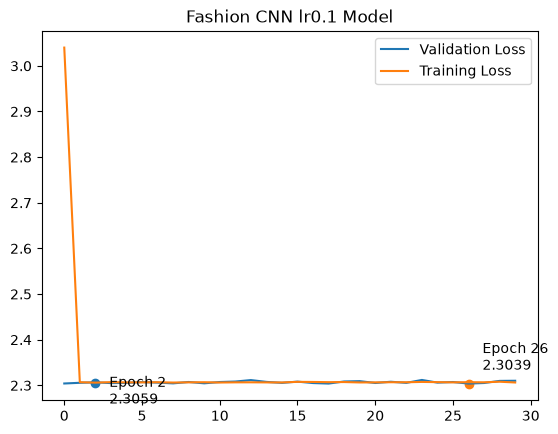

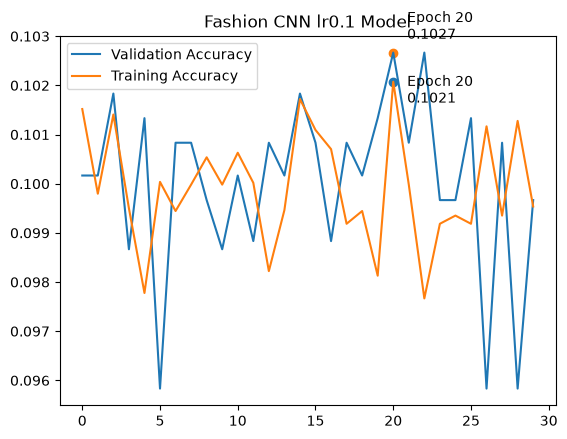

In [8]:
model_01 = FashionMnistCNN()

optimizer_01 = torch.optim.Adam(
    model_01.parameters(),
    lr=0.1
)

loss_fn = nn.CrossEntropyLoss()

train_fashion_cnn_model(model=model_01, optimizer=optimizer_01, loss_fn=loss_fn, postfix="lr0.1")

### Learning Rate = 0.01

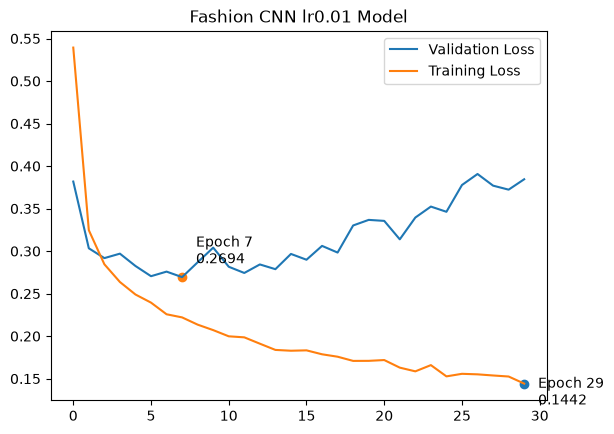

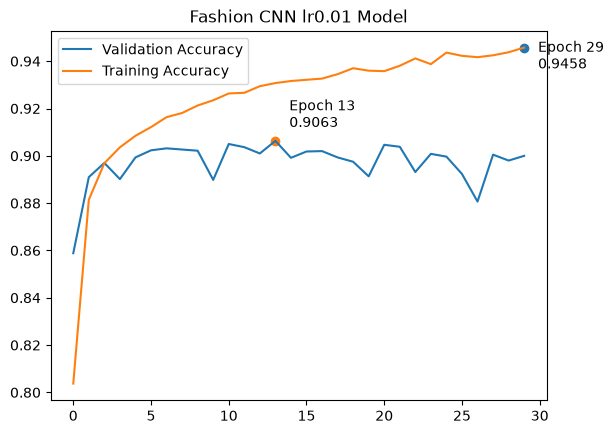

In [9]:
model_001 = FashionMnistCNN()

optimizer_001 = torch.optim.Adam(
    model_001.parameters(),
    lr=0.01
)

loss_fn = nn.CrossEntropyLoss()

train_fashion_cnn_model(model=model_001, optimizer=optimizer_001, loss_fn=loss_fn, postfix="lr0.01")

### Learning Rate = 0.001

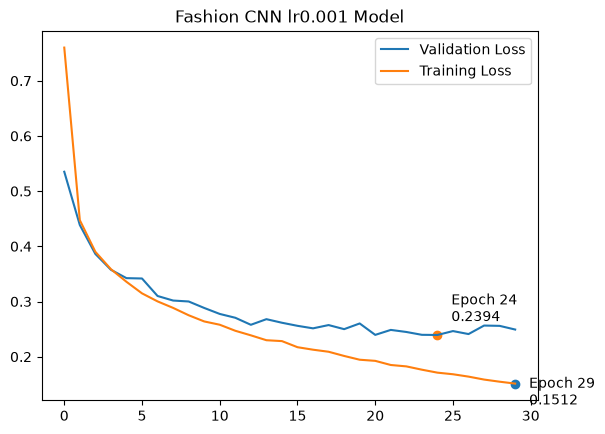

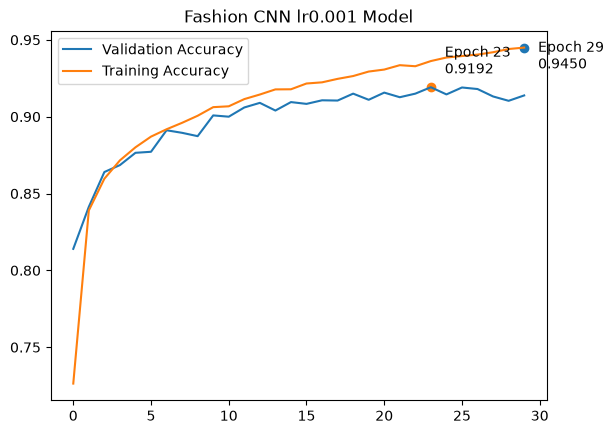

In [10]:
model_0001 = FashionMnistCNN()

optimizer_0001 = torch.optim.Adam(
    model_0001.parameters(),
    lr=0.001
)

loss_fn = nn.CrossEntropyLoss()

train_fashion_cnn_model(model=model_0001, optimizer=optimizer_0001, loss_fn=loss_fn, postfix="lr0.001")

### Which experiment converges?
- The LR = 0.1 experiment failed to learn effectively. Its metrics quickly became nearly constant, but this is not useful convergence because the model remained around random-guessing performance. While LR = 0.01 and LR = 0.001 converges.

### Which is unstable?
- LR = 0.1 is the most unstable. Its accuracy fluctuates heavily around ~10% and the loss quickly becomes stuck around 2.3, indicating that the updates are too aggressive for the model to make useful learning progress.

### Which converges slowly?
- LR = 0.001 is converging slowly, but it is also much more stable and achieves sustained useful learning.

### If LR = 0.001 eventually reaches ~92% validation accuracy but LR = 0.01 reaches ~90% very quickly, why might we still prefer LR = 0.001 despite requiring more epochs?
- We may prefer LR = 0.001 because, although it learns more slowly, it continues improving on validation data for longer and achieves better generalization. LR = 0.01 learns faster initially but begins overfitting earlier, so its faster optimization does not translate into better validation performance.

## Why Fixed Learning Rate Can Be Limiting

### Should the same learning rate necessarily remain appropriate throughout training?
- No, A learning rate that works well early in training may not be ideal later. A relatively larger learning rate can make rapid progress initially, while reducing it later allows smaller, more precise parameter updates around a good solution.

### What would you want to happen to the learning rate later in training?
- I would generally want the learning rate to decrease later in training so that the optimizer can make smaller updates and refine the model after the larger improvements have already been made.

## Learning Rate Scheduler

In [11]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

### What does step_size control?
- step_size determines how many epochs pass before the scheduler applies a learning-rate update.

### What does gamma control?
- gamma is the multiplicative factor applied to the learning rate each time the scheduler decays it.

### How does the learning rate change over time?
- If it starts with 0.001 then it remains 0.001 for first 10 epoch then for 10-20 epoch learning rate becomes 0.001 * 0.1 = 0.0001 and for next 10 epoch (20-30) it becomes 0.00001 now this continues till model has completed it's training.

## Inspect the Learning Rate

In [12]:
import os
import gc

fashion_cnn_scheduler_model = FashionMnistCNN()

device = torch.device("cuda")

fashion_cnn_model = fashion_cnn_scheduler_model.to(device)

optimizer = torch.optim.Adam(
    fashion_cnn_scheduler_model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

fashion_cnn_scheduler_model_train_losses = []
fashion_cnn_scheduler_model_val_losses = []
fashion_cnn_scheduler_model_train_accuracies = []
fashion_cnn_scheduler_model_val_accuracies = []

loss_fn = nn.CrossEntropyLoss()

best_val_loss = float("inf")

fashion_checkpoint_path = "/home/taksh/Coding/Learn/ml-learning-journey/static/tmp"

if os.path.exists(os.path.join(fashion_checkpoint_path, "best_fashion_cnn_scheduler_model.pt")):
    fashion_cnn_model.load_state_dict(torch.load(
        os.path.join(fashion_checkpoint_path, "best_fashion_cnn_scheduler_model.pt"),
        map_location=device
    ))

    fashion_cnn_scheduler_model_train_losses = np.load(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_train_losses.npy"))
    fashion_cnn_scheduler_model_val_losses = np.load(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_val_losses.npy"))
    fashion_cnn_scheduler_model_train_accuracies = np.load(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_train_accuracies.npy"))
    fashion_cnn_scheduler_model_val_accuracies = np.load(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_val_accuracies.npy"))

if not os.path.exists(os.path.join(fashion_checkpoint_path, "best_fashion_cnn_scheduler_model.pt")):

    for epoch in range(30):
        
        fashion_cnn_scheduler_model.train()
            
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            pred = fashion_cnn_model(images)
            
            loss = loss_fn(pred, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            
            correct += (pred.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader)
        train_accuracy = correct / total
            
        # Validation
        fashion_cnn_model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                pred = fashion_cnn_model(images)
                
                loss = loss_fn(pred, labels)

                val_loss += loss.item()
                
                correct += (pred.argmax(dim=1) == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_accuracy = correct / total

        scheduler.step()

        print(
            f"Epoch: {epoch:02} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f} | "
            f"Learning Rate: {scheduler.get_last_lr()[0]} |"
        )
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(fashion_cnn_scheduler_model.state_dict(), os.path.join(fashion_checkpoint_path, "best_fashion_cnn_scheduler_model.pt"))

        fashion_cnn_scheduler_model_train_losses.append(train_loss)
        fashion_cnn_scheduler_model_val_losses.append(val_loss)
        fashion_cnn_scheduler_model_train_accuracies.append(train_accuracy)
        fashion_cnn_scheduler_model_val_accuracies.append(val_accuracy)

    np.save(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_train_losses.npy"), fashion_cnn_scheduler_model_train_losses)
    np.save(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_val_losses.npy"), fashion_cnn_scheduler_model_val_losses)
    np.save(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_train_accuracies.npy"), fashion_cnn_scheduler_model_train_accuracies)
    np.save(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_val_accuracies.npy"), fashion_cnn_scheduler_model_val_accuracies)

gc.collect()
torch.cuda.empty_cache()

Epoch: 00 | Train Loss: 0.7675 | Train Accuracy: 0.7263 | Val Loss: 0.5068 | Val Accuracy: 0.8233 | Learning Rate: 0.001 |
Epoch: 01 | Train Loss: 0.4497 | Train Accuracy: 0.8369 | Val Loss: 0.4147 | Val Accuracy: 0.8523 | Learning Rate: 0.001 |
Epoch: 02 | Train Loss: 0.3891 | Train Accuracy: 0.8597 | Val Loss: 0.3824 | Val Accuracy: 0.8620 | Learning Rate: 0.001 |
Epoch: 03 | Train Loss: 0.3546 | Train Accuracy: 0.8721 | Val Loss: 0.3473 | Val Accuracy: 0.8812 | Learning Rate: 0.001 |
Epoch: 04 | Train Loss: 0.3312 | Train Accuracy: 0.8820 | Val Loss: 0.3363 | Val Accuracy: 0.8813 | Learning Rate: 0.001 |
Epoch: 05 | Train Loss: 0.3158 | Train Accuracy: 0.8869 | Val Loss: 0.3148 | Val Accuracy: 0.8870 | Learning Rate: 0.001 |
Epoch: 06 | Train Loss: 0.3002 | Train Accuracy: 0.8922 | Val Loss: 0.3029 | Val Accuracy: 0.8932 | Learning Rate: 0.001 |
Epoch: 07 | Train Loss: 0.2876 | Train Accuracy: 0.8971 | Val Loss: 0.2946 | Val Accuracy: 0.8965 | Learning Rate: 0.001 |
Epoch: 08 | Trai

### Does the learning rate actually change when expected?
- Yes, It changes every 10 epoch. It is multiplied my gamma ever 10 epoch thus causing decay in learning rate. 

### Does the loss behavior change after the learning-rate reduction?
- Yes. After each learning-rate reduction, the loss generally changes more slowly because the optimizer takes smaller parameter updates. This can allow finer optimization, although reducing the learning rate too aggressively can make further learning unnecessarily slow.

## Compare Fixed vs Scheduled Learning Rate

### Training vs Validation loss and accuracies plot of Model with Scheduler

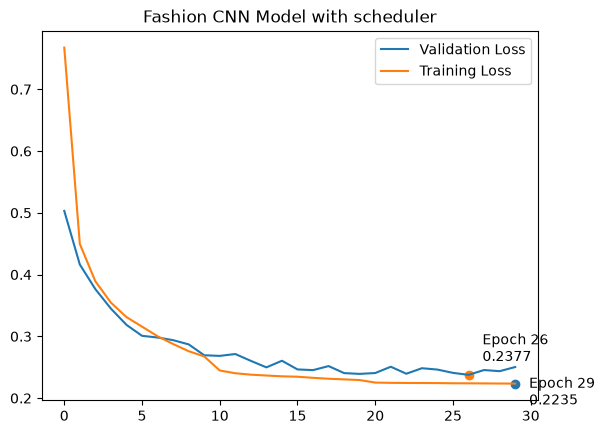

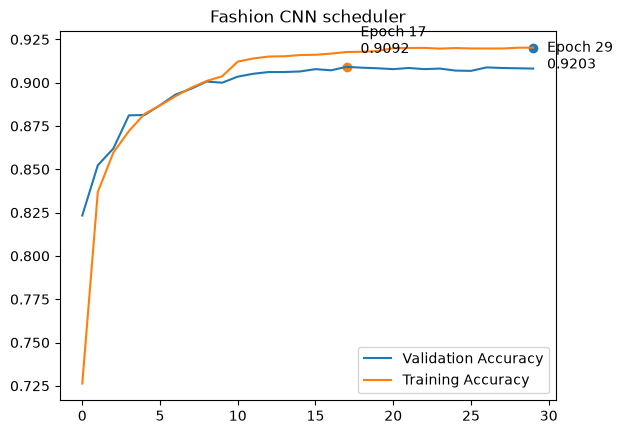

In [13]:
plot_train_val_loss_curve(fashion_cnn_scheduler_model_train_losses, fashion_cnn_model_val_losses, "Fashion CNN Model with scheduler")
plot_train_val_accuracy_curve(fashion_cnn_scheduler_model_train_accuracies, fashion_cnn_scheduler_model_val_accuracies, "Fashion CNN scheduler")

### Training vs Validation loss and accuracies plot of Model with Fixed learning rate 0.001

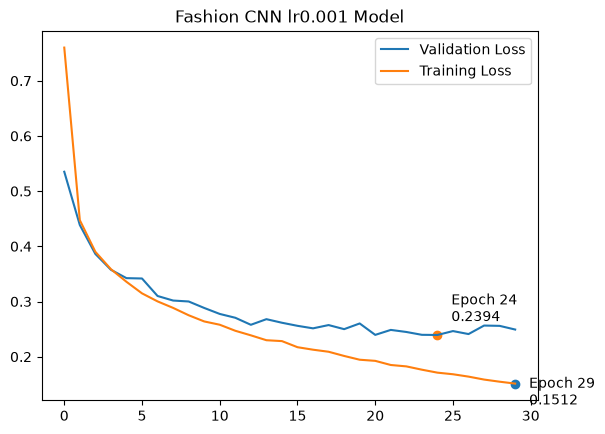

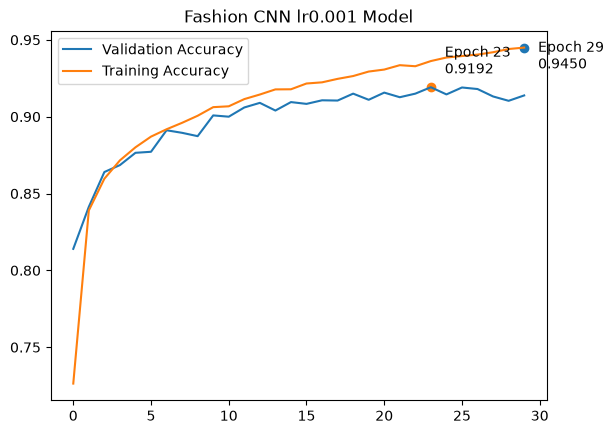

In [14]:
model_0001 = FashionMnistCNN()

optimizer_0001 = torch.optim.Adam(
    model_0001.parameters(),
    lr=0.001
)

loss_fn = nn.CrossEntropyLoss()

train_fashion_cnn_model(model=model_0001, optimizer=optimizer_0001, loss_fn=loss_fn, postfix="lr0.001")

### Did scheduling actually improve the result?
- The scheduler produced a small improvement in minimum validation loss and delayed the minimum validation loss slightly, but the improvement is small and validation accuracy does not show a corresponding improvement. Therefore, the scheduler's overall benefit is inconclusive from this single experiment.

### If not, what does that tell you?
- Training with scheduler does not necessarily means improvement in performance then model with fixed learning rate.

### Why shouldn't a scheduler automatically be considered an improvement?
- A scheduler should not automatically be considered an improvement because changing the learning rate only changes the optimization strategy. It does not guarantee better validation performance, faster convergence, or better generalization. The scheduler must be evaluated against a fixed-learning-rate baseline using appropriate validation metrics.

## Conclusion of comparing model trained with scheduled learning rate and fixed learning rate. 

### Hypothesis
- Reducing the learning rate during training may allow finer optimization after the initial learning phase.

### Observation
- StepLR reduced the LR as expected.
- Validation loss reached approximately 0.2377, compared with 0.2394 for fixed LR.
- The scheduler's best validation loss occurred slightly later.
- Validation accuracy did not clearly improve.
- The scheduler therefore produced a small change, but not a convincing overall improvement.

### Conclusion
- For this particular FashionMNIST CNN training run, StepLR with step_size=10 and gamma=0.1 did not demonstrate a substantial improvement over fixed LR = 0.001. The small validation-loss improvement is insufficient by itself to establish that scheduling is beneficial.

## ReduceLROnPlateau

In [15]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.1
)

In [16]:
import os
import gc

fashion_cnn_scheduler_model = FashionMnistCNN()

device = torch.device("cuda")

fashion_cnn_model = fashion_cnn_scheduler_model.to(device)

optimizer = torch.optim.Adam(
    fashion_cnn_scheduler_model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.1
)

fashion_cnn_scheduler_model_train_losses = []
fashion_cnn_scheduler_model_val_losses = []
fashion_cnn_scheduler_model_train_accuracies = []
fashion_cnn_scheduler_model_val_accuracies = []

loss_fn = nn.CrossEntropyLoss()

# best_val_loss = float("inf")

# fashion_checkpoint_path = "/home/taksh/Coding/Learn/ml-learning-journey/static/tmp"

# if os.path.exists(os.path.join(fashion_checkpoint_path, "best_fashion_cnn_scheduler_model.pt")):
#     fashion_cnn_model.load_state_dict(torch.load(
#         os.path.join(fashion_checkpoint_path, "best_fashion_cnn_scheduler_model.pt"),
#         map_location=device
#     ))

#     fashion_cnn_scheduler_model_train_losses = np.load(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_train_losses.npy"))
#     fashion_cnn_scheduler_model_val_losses = np.load(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_val_losses.npy"))
#     fashion_cnn_scheduler_model_train_accuracies = np.load(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_train_accuracies.npy"))
#     fashion_cnn_scheduler_model_val_accuracies = np.load(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_val_accuracies.npy"))

# if not os.path.exists(os.path.join(fashion_checkpoint_path, "best_fashion_cnn_scheduler_model.pt")):

for epoch in range(30):
    
    fashion_cnn_scheduler_model.train()
        
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        pred = fashion_cnn_model(images)
        
        loss = loss_fn(pred, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        
        correct += (pred.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_accuracy = correct / total
        
    # Validation
    fashion_cnn_model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            pred = fashion_cnn_model(images)
            
            loss = loss_fn(pred, labels)

            val_loss += loss.item()
            
            correct += (pred.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = correct / total

    scheduler.step(val_loss)

    print(
        f"Epoch: {epoch:02} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f} | "
        f"Learning Rate: {scheduler.get_last_lr()[0]} |"
    )
    
    # if val_loss < best_val_loss:
    #     best_val_loss = val_loss
    #     torch.save(fashion_cnn_scheduler_model.state_dict(), os.path.join(fashion_checkpoint_path, "best_fashion_cnn_scheduler_model.pt"))

    fashion_cnn_scheduler_model_train_losses.append(train_loss)
    fashion_cnn_scheduler_model_val_losses.append(val_loss)
    fashion_cnn_scheduler_model_train_accuracies.append(train_accuracy)
    fashion_cnn_scheduler_model_val_accuracies.append(val_accuracy)

# np.save(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_train_losses.npy"), fashion_cnn_scheduler_model_train_losses)
# np.save(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_val_losses.npy"), fashion_cnn_scheduler_model_val_losses)
# np.save(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_train_accuracies.npy"), fashion_cnn_scheduler_model_train_accuracies)
# np.save(os.path.join(fashion_checkpoint_path, "fashion_cnn_scheduler_model_val_accuracies.npy"), fashion_cnn_scheduler_model_val_accuracies)

gc.collect()
torch.cuda.empty_cache()

Epoch: 00 | Train Loss: 0.7670 | Train Accuracy: 0.7305 | Val Loss: 0.5244 | Val Accuracy: 0.8140 | Learning Rate: 0.001 |
Epoch: 01 | Train Loss: 0.4503 | Train Accuracy: 0.8369 | Val Loss: 0.4298 | Val Accuracy: 0.8455 | Learning Rate: 0.001 |
Epoch: 02 | Train Loss: 0.3860 | Train Accuracy: 0.8622 | Val Loss: 0.3744 | Val Accuracy: 0.8718 | Learning Rate: 0.001 |
Epoch: 03 | Train Loss: 0.3513 | Train Accuracy: 0.8744 | Val Loss: 0.3716 | Val Accuracy: 0.8693 | Learning Rate: 0.001 |
Epoch: 04 | Train Loss: 0.3274 | Train Accuracy: 0.8829 | Val Loss: 0.3314 | Val Accuracy: 0.8832 | Learning Rate: 0.001 |
Epoch: 05 | Train Loss: 0.3085 | Train Accuracy: 0.8900 | Val Loss: 0.3268 | Val Accuracy: 0.8840 | Learning Rate: 0.001 |
Epoch: 06 | Train Loss: 0.2918 | Train Accuracy: 0.8946 | Val Loss: 0.3067 | Val Accuracy: 0.8870 | Learning Rate: 0.001 |
Epoch: 07 | Train Loss: 0.2820 | Train Accuracy: 0.8997 | Val Loss: 0.3055 | Val Accuracy: 0.8887 | Learning Rate: 0.001 |
Epoch: 08 | Trai

- As it can be seen whenever validation loss stops improving learning rate is updated. It happened at around epoch 22 and 29.

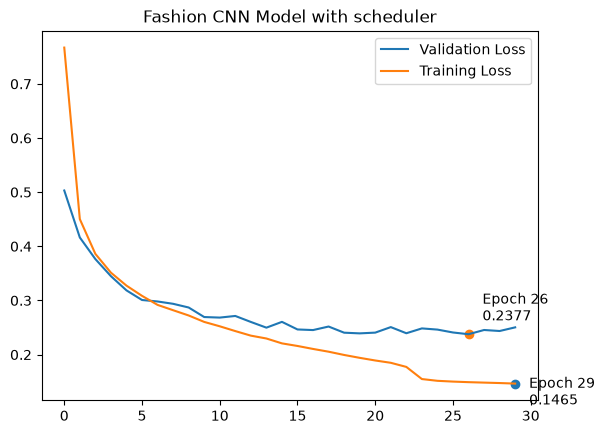

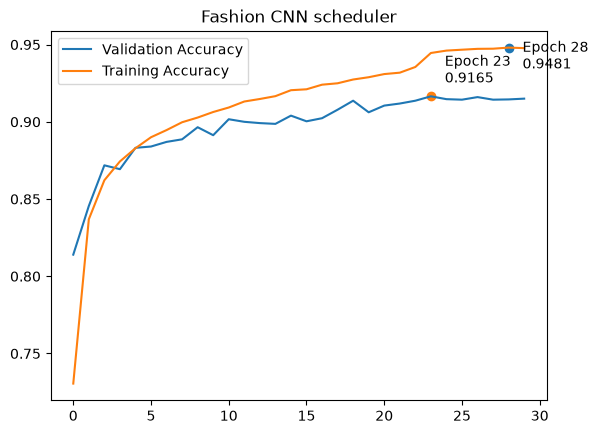

In [17]:
plot_train_val_loss_curve(fashion_cnn_scheduler_model_train_losses, fashion_cnn_model_val_losses, "Fashion CNN Model with scheduler")
plot_train_val_accuracy_curve(fashion_cnn_scheduler_model_train_accuracies, fashion_cnn_scheduler_model_val_accuracies, "Fashion CNN scheduler")

### What is different about this scheduler?
- StepLR changes the learning rate according to a predefined epoch schedule, whereas ReduceLROnPlateau changes the learning rate when a monitored metric, such as validation loss, stops improving.

### Why might validation loss be a better signal than epoch number?
- Validation loss measures how well the model is performing on unseen validation data, including the quality and confidence of its predictions. Therefore, it can indicate when further training is no longer producing meaningful improvement, whereas epoch number only tells us how long the model has been training.

### What does patience mean?
- `patience` specifies how many consecutive epochs without sufficient improvement in the monitored metric the scheduler will tolerate before reducing the learning rate.

## Early Stopping vs Learning Rate Scheduling

### Are these solving the same problem?
- Early stopping terminates training when validation performance stops improving, often preventing unnecessary training and overfitting. Learning-rate scheduling instead changes the learning rate during training to alter the optimization behavior and allow finer parameter updates.

### What does early stopping do?
- Early stopping stops training when the monitored validation metric has failed to improve for a specified number of epochs.

### What does a scheduler do?
- A learning-rate scheduler changes the optimizer's learning rate according to a predefined rule. For example, StepLR uses epoch-based decay, while ReduceLROnPlateau reacts to whether a monitored metric has stopped improving.

## Best Model Checkpoint

### Why can the final model be worse than an earlier model?
- The final model can be worse because continued training may reduce training loss while validation performance deteriorates due to overfitting. Therefore, a later epoch can have better training performance but worse generalization than an earlier epoch.

### What should you save when validation performance improves?
- We should save model (parameter's values) when validation performance improves.

## Training Diagnostic Exercise

- Given:

        Epoch 01  train loss = 0.65   val loss = 0.62
        Epoch 05  train loss = 0.40   val loss = 0.39
        Epoch 10  train loss = 0.20   val loss = 0.35
        Epoch 20  train loss = 0.08   val loss = 0.51

### At what point does overfitting become apparent?
- Overfitting is apparent sometime after epoch 10 and is clearly evident by epoch 20.

### Would increasing model capacity make sense?
- No, Increasing capacity would generally be a poor first intervention because the current evidence already shows the model fits the training data substantially better than the validation data.

### Would training longer make sense?
- No

### What intervention would you test first?
- First use early stopping and save the best validation checkpoint. Then test whether reducing or scheduling the learning rate changes the validation behavior.

## Diagnostic Decision Tree

        Model isn't improving
                ↓
        Check training loss
                ↓
                ?

### You should determine what you would inspect next for:

### A. training loss doesn't decrease
- Learning rate could be too small or inappropriate and check whether implementation is correct like parameters are being updated or targeted model is correct.

### B. training loss decreases but validation loss increases
- Inspect best validation checkpoint, Early stopping, Model capacity, Regularization, etc.

### C. both decrease but very slowly
- Learning rate potentially too small, Training curves to determine whether progress is genuinely gradual or has plateaued.

### D. training and validation performance are both poor
- Model capacity / underfitting, Learning rate, Features/input representation, Data quality, Loss/target configuration and Training procedure.

## Critical Reflection

1. How can you distinguish an optimization problem from an overfitting problem?
- Train loss ↓, validation loss ↑ → strong evidence of overfitting / worsening generalization.
- Training loss doesn't decrease or decreases extremely slowly → possible optimization problem, but you still need to investigate why.
- Unstable loss → suggests an optimization issue, but again, it's evidence rather than proof.

2. When would changing the learning rate be more justified than changing the architecture?
- When loss is decreasing but too slowly or loss is changing very rapidly suggesting unstable learning.

3. Why is validation performance necessary for deciding whether training should continue?
- Validation performance provides an estimate of how well the model generalizes beyond the training data. Training loss can continue improving while validation performance deteriorates, so validation performance helps determine whether additional training is actually beneficial.

4. Can learning-rate scheduling make a fundamentally bad model good? Why or why not?
- No, Learning-rate scheduling changes the optimization process, but it cannot compensate for a fundamentally unsuitable architecture, inadequate data, incorrect targets, or other fundamental problems. It can potentially improve optimization speed, stability, or the final solution reached by the optimizer.